# Visualization & simple model for $R_0$


$R_0$: "The average/expected number of secondary infections arising from a single individual during his or her entire infectious period, in a population of susceptibles" (Heffernan et al, 2005)

Goal: $R_0$ has not been reliably estimated for E. coli. With the available data set and likelihood-free inference tools, could we find this via simulation?


States:
- $C_s$: colonized by a specific E. coli strain of interest $s$.
- $I_s$: infected by e.coli (strain of interest or any?)
- $S$: susceptible to colonization by strain $s$. In other words, colonized by any other strain than $s$ or not colonized at all.

Parameters:
- $C_s$ -> S: Colonization by strain $s$ is "cleared", i.e, actually dissapears (caused for example by usage of antibiotics), or becomes replaced by another strain.
- $C_s$ -> I: Colonization develops into an infection
- (I -> $C_s$: Infected patient goes back to colonized state by strain $s$. Assumed to be neglible?)
- S -> $C_s$: susceptible individual is colonized by strain $s$
- I -> S: Infected patient goes back to susceptible state (maybe use of antibiotics clears the colonization? or the strain that infected the patient in the first place is not "strong enough" -> clearance.)

There should be a rate parameter for each of these transitions. They are then simulated using likelihood-free inference, more specifically the ELFI tool. (Lintusaari et al, 2018)

Through simulations, we can find the set of parameters that most closely matches the data. The inferred parameters can be used to determine $R_0$ (how?)

Simplifications:
- Stratification by age groups: at first, no stratification, just see the evolvement of the entire population.
- One-vs-all approach to strains/CCs/STs

Simplifications can be expanded on later.

Future model configurations:
- Stratification by age group, complex strain dynamics
- IBM/ABM with one-vs-all strains. 
- Endgame: ABM with complex strain dynamics (c++?)



## Practicalities
To install to the correct python version, use `python3 -m pip install seaborn` otherwise will use some old Python v2. Do this via jupyter terminal. Also restart jupyter after installing packages, fixed "ModuleNotFound" error for me :)

Required packages (TODO: create anaconda environment ASAP)
- xlrd (to read excel files) DEPRECATED support for xlsx files, use `openpyxl` instead.

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

## Part 1: Preprocessing

Good to know:
- [add something]


BSAC data downloaded from (Supplemental_Data_S1.csv): https://genome.cshlp.org/content/suppl/2017/06/29/gr.216606.116.DC1


In [2]:
# load NORM data

norm_data = pd.read_excel("data/mmc2.xlsx", engine = 'openpyxl') # this is the NORM data


# load BSAC data
bsac_data = pd.read_csv("data/Supplemental_Data_S1.csv")


df = norm_data


# load babybiome data
or_data = pd.read_csv("data/ST131_clades_OR_E_coli_carriage_disease_collapsed.csv")

In [3]:
# take a look
print(df.shape)
print(df.columns)
df.head()

(3254, 63)
Index(['lane', 'Run accession', 'popPUNK_cluster', 'ST', 'CC131_clades',
       'Duplicate', 'year', 'Lab', 'Hospital name',
       'Regional health authority', 'Clermont_Phylotype', 'FimH', 'folP',
       'gyrA', 'parC', 'gyrA_parC', 'parE', 'pmrB', 'blaTEM1', 'strB', 'sul2',
       'strA', 'sul1', 'dfrA', 'tetA', 'tetB', 'aadA', 'mphA', 'dfrA1',
       'aac3_Iia', 'catA1', 'dfrA5', 'CTX-M-type', 'CTX-M', 'dfrA14', 'blaOXA',
       'aph3', 'catB3', 'acc', 'blaSHV', 'dfrA12', 'sul3', 'cmlA1', 'dfrA8',
       'C_mefB', 'QnrS1', 'floR', 'Ampicillin_SIR', 'Aztreonam_SIR',
       'Cefotaxim_SIR', 'Ceftazidim_SIR', 'Cefuroxim_SIR', 'Ciprofloxacin_SIR',
       'Ciprofloxacin_NS', 'ESBL', 'Gentamicin_SIR', 'Meropenem_SIR',
       'Nalidixin_SIR', 'Piperacillin_tazobactam_SIR', 'Sulfa_SIR',
       'Tigecyklin_SIR', 'Tobramycin_SIR', 'Trimetoprim_sulfa_SIR'],
      dtype='object')


,lane,Run accession,popPUNK_cluster,ST,CC131_clades,Duplicate,year,Lab,Hospital name,Regional health authority,...,Ciprofloxacin_NS,ESBL,Gentamicin_SIR,Meropenem_SIR,Nalidixin_SIR,Piperacillin_tazobactam_SIR,Sulfa_SIR,Tigecyklin_SIR,Tobramycin_SIR,Trimetoprim_sulfa_SIR
0,30134_6#100,ERR4034085,1,73,NaN,NaN,2004,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,NaN,NaN,S
1,30134_6#101,ERR4034086,8,127,NaN,NaN,2015,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,I,NaN,S,NaN,S
2,30134_6#103,ERR4034087,3,69,NaN,NaN,2013,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,S,NaN,R
3,30134_6#104,ERR4034088,1,73,NaN,NaN,2005,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,NaN,NaN,S
4,30134_6#105,ERR4034089,5,537,NaN,NaN,2011,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,S,NaN,S


In [4]:
# describe
df.describe(include=['object']) # use 'object' for categorical data

,lane,Run accession,CC131_clades,Duplicate,Lab,Hospital name,Regional health authority,Clermont_Phylotype,FimH,folP,...,Ciprofloxacin_SIR,Ciprofloxacin_NS,ESBL,Gentamicin_SIR,Meropenem_SIR,Nalidixin_SIR,Piperacillin_tazobactam_SIR,Tigecyklin_SIR,Tobramycin_SIR,Trimetoprim_sulfa_SIR
count,3254,3254,278,3,3254,3254,3254,3254,3254,2,...,3253,3254,2075,3254,3085,798,3254,2501,196,3254
unique,3254,3254,6,2,15,15,4,11,263,1,...,3,2,4,3,3,2,3,4,3,3
top,30134_6#100,ERR4034085,A,Duplicated in plate,Haukeland,Haukeland universitetssykehus,Helse Sør-Øst,B2,fimH27,folP.P64S,...,S,S,-,S,S,S,S,S,S,S
freq,1,1,75,2,399,399,1625,2180,521,2,...,2876,2876,1263,2992,3081,705,3109,2480,188,2401


## Part 2: Visualization

Figure 1: Barplot of the counts of STs (10 most common)

Figure 2: Barplot of the counts of STs over time


How cool would that be to:
- Create an interactive network visualization of the counts of specific STs etc in specific hospitals! And then you could cycle through the years.

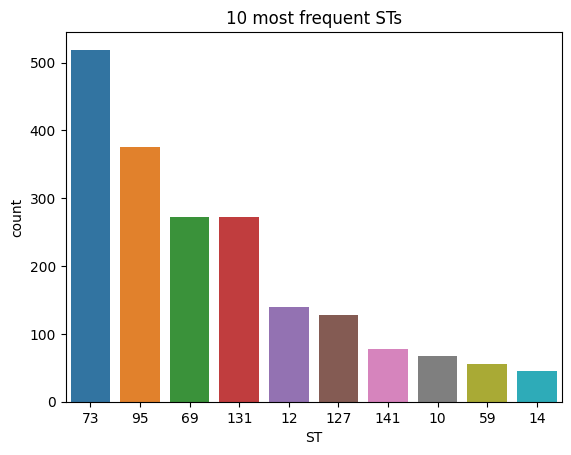

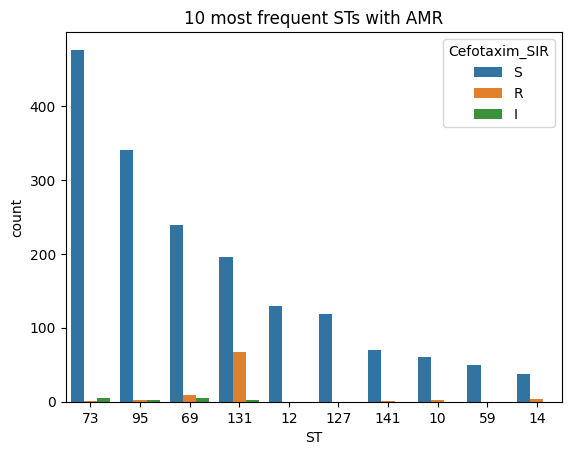

In [5]:
feat = "ST"
N = 10

# ten most frequent STs
sns.countplot(data = df, x = feat, order = pd.value_counts(df[feat]).iloc[:N].index)
plt.title(str(N) + " most frequent " + feat + "s")
plt.show()

amr = 'Cefotaxim_SIR'
sns.countplot(data = df, x = feat, order = pd.value_counts(df[feat]).iloc[:N].index, hue = amr)
plt.title(str(N) + " most frequent " + feat + "s with AMR")
plt.show()

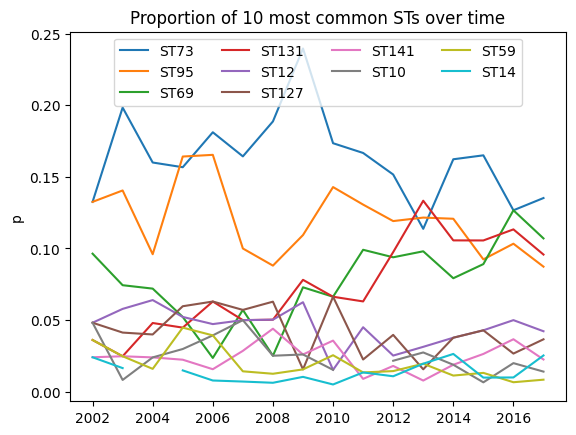

In [6]:
# plot the ten most common STs over time
st = 131
df_vis = pd.value_counts(df.loc[df['ST'] == st]["year"])/pd.value_counts(df["year"])
for st in pd.value_counts(df["ST"]).iloc[:N].index:
    df_vis = pd.value_counts(df.loc[df['ST'] == st]["year"]).sort_index()/pd.value_counts(df["year"]).sort_index()
    plt.plot(df_vis.index, df_vis, label = "ST" + str(st))
plt.legend(loc="upper center", ncol = 4)
plt.ylabel("p")
plt.title("Proportion of " + str(N) + " most common STs over time")
plt.show()

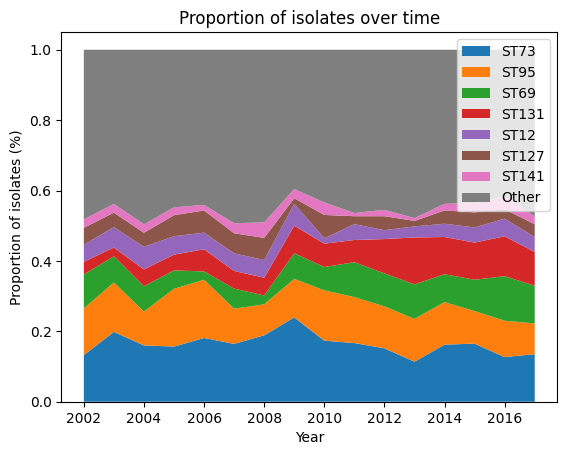

In [7]:
# the stackplot recreation
y = []
x = pd.value_counts(df["year"]).sort_index().index
N = 7
for st in pd.value_counts(df["ST"]).iloc[:N].index:
    y.append(list(pd.value_counts(df.loc[df['ST'] == st]["year"]).sort_index()/pd.value_counts(df["year"]).sort_index()))

# todo: add an aggregate column that has all the other STs stacked to one line
other_sts = list(pd.value_counts(df["ST"]).iloc[N:len(np.unique(df["ST"]))].index) # the other STs
y_other = list(pd.value_counts(df.loc[df['ST'].isin(other_sts)]["year"])/pd.value_counts(df["year"]).sort_index())
# labels
labs = ["ST" + str(i) for i in list(pd.value_counts(df["ST"]).iloc[:N].index)]
labs.append("Other")

# combine
y.append(y_other)

plt.stackplot(x,y,labels=labs)
plt.legend(loc='upper right')
plt.title("Proportion of isolates over time")
plt.ylabel("Proportion of isolates (%)")
plt.xlabel("Year")
plt.show()



TODO: proportion barplot t and t+1, one-vs-all approach. Basically rate params from data. Probably requires quite heavy reshaping of the data.

- Problem: how to infer the porportion of colonized, susceptible and infected, when the data contains colonized cases (or actually infected?) Solution: by comparing 1 ST to all other ST:s. Colonized by some other st = not colonized at all :)

[2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
             p     t
2002  0.036145  2002
2003  0.024793  2003
2004  0.048000  2004
2005  0.044776  2005
2006  0.062992  2006
(16, 2)
RangeIndex(start=0, stop=3254, step=1)
Index(['p', 't'], dtype='object')


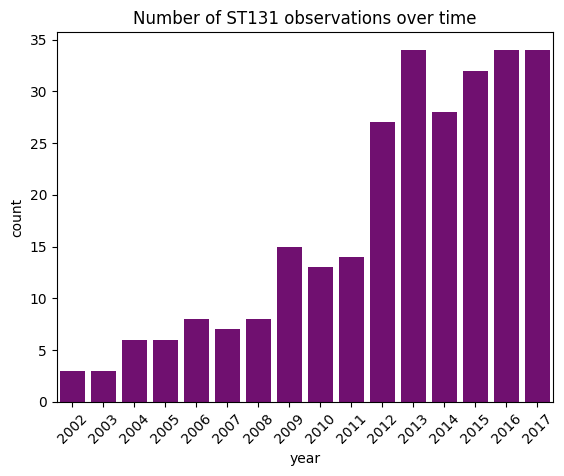

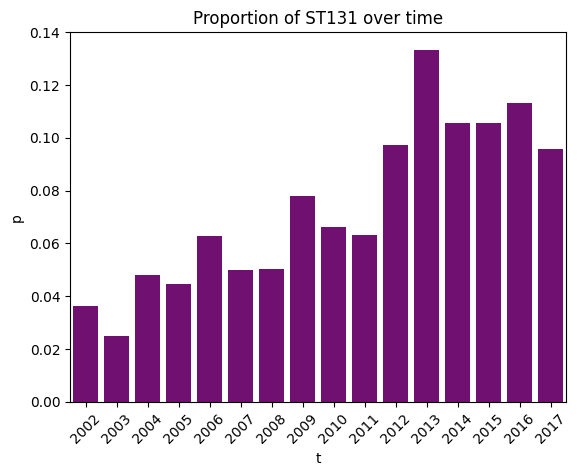

In [8]:
# TODO

df.head(5)


st = 131

# plot the proportion of ST31 over each year. Barplot with CIs. Or boxplot?

# step 1: calculate the prop of the st of interest for one year
year = 2004

df_vis = pd.DataFrame(pd.value_counts(df.loc[df['ST'] == st]["year"])/pd.value_counts(df["year"])).rename(columns = {"year": "p"}) # same as the line plot


years = [row for row in df_vis.index]
df_vis["t"] = years
print(years)

print(df_vis.head(5))
print(df_vis.shape)
print(df.index)
print(df_vis.columns)

# one vs all: number of observations
sns.countplot(data = df.loc[df['ST'] == st], x = "year", color = "purple")
plt.title("Number of ST" + str(st) + " observations over time")
plt.xticks(rotation = 45)
plt.show()

# one vs all: proportion of observations
sns.barplot(data = df_vis, x = "t", y = "p", color = "purple")
plt.title("Proportion of ST" + str(st) + " over time")
plt.xticks(rotation = 45)
plt.show()


In [9]:
# Event matrix type visualisation: ST-ST matrix.
# Paitsi että eihän tämä ole järkevä, koska tässä aina yhdeltä individualilta
# saadaan yksi näyte. TODO: replikoi vauvadatalle.

In [10]:
print("Total number of observations:", norm_data.shape[0])
print("ST131 observations:", norm_data.loc[norm_data['ST'] == 131].shape[0])

Total number of observations: 3254
ST131 observations: 272


## Replicating Odds Ratio calculations


Invasiveness is the ratio of the frequencies of carriage (newborns) and disease (BSI).


OR = (c0/d0)/(ca/da) = da/ca * c0/d0 = (da/ca)/(d0/c0)


$$OR = \frac{inv_a}{inv_0} = \frac{\frac{d_a}{c_a}}{\frac{d_0}{c_0}} = \frac{d_ac_0}{c_ad_0}$$

Odds ratio is calculated between `PP` and `nonPP`. PP = popPUNK. PP = clade A, nonPP = not clade A for example. 

Rebecca's message: 

$$OR = \frac{inv_a}{inv_0} = \frac{d_ac_0}{c_ad_0},$$ where $a = $ clade A for example, and zero means non-clade A.

Now it makes sense!

In [11]:

print(or_data.columns)
print(or_data.head(10))

print((or_data['carriage_nonPP']/or_data['Disease_nonPP'])/(or_data['carriage_PP']/or_data['Disease_PP'])) # this is how the OR is calculated.
#print(or_data["OR"]) # to check

Index(['Collection', 'Clade', 'Label', 'carriage_nonPP', 'Disease_nonPP',
       'carriage_PP', 'Disease_PP', 'OR', 'lower', 'upper', 'pval_f<=5_chi>5',
       'p.adj BH'],
      dtype='object')
  Collection Clade          Label  carriage_nonPP  Disease_nonPP  carriage_PP  \
0       NORM     A       A (NORM)             387           3179           16   
1       BSAC     A       A (BSAC)             387           1490           16   
2   Combined     A   A (Combined)             387           4669           16   
3       NORM     B       B (NORM)             389           3172           14   
4       BSAC     B       B (BSAC)             389           1464           14   
5   Combined     B   B (Combined)             389           4636           14   
6       NORM    C1      C1 (NORM)             399           3184            4   
7       BSAC    C1      C1 (BSAC)             399           1487            4   
8   Combined    C1  C1 (Combined)             399           4671            

## BSAC data

In [12]:
print(bsac_data.columns)
bsac_data.head()

Index(['ERS accession', 'ERR accession', 'Collection', 'BSAC_or_CUH_number',
       'Year_of_isolation', 'Sequencing depth', 'MLST', 'Phylogroup',
       'serotype', 'H30Rx',
       ...
       'oqxA_1_EU370913', 'oqxB_1_EU370913', 'qepA_1_AB263754',
       'strA_1_M96392', 'strB_1_M96392', 'sul1_11_DQ914960', 'sul2_1_AF542061',
       'sul3_2_AJ459418', 'tetA_2_X00006', 'tetB_3_AP000342'],
      dtype='object', length=407)


,ERS accession,ERR accession,Collection,BSAC_or_CUH_number,Year_of_isolation,Sequencing depth,MLST,Phylogroup,serotype,H30Rx,...,oqxA_1_EU370913,oqxB_1_EU370913,qepA_1_AB263754,strA_1_M96392,strB_1_M96392,sul1_11_DQ914960,sul2_1_AF542061,sul3_2_AJ459418,tetA_2_X00006,tetB_3_AP000342
0,ERS357183,ERR435312,BSAC,eo100,2001,76.628483,68,D,NA:H6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tetB_4_AF326777
1,ERS357556,ERR434919,BSAC,eo1011,2005,78.691295,652,A,NA:H9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ERS357557,ERR434399,BSAC,eo1013,2005,84.620679,95,B2,O1:H7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ERS357558,ERR434695,BSAC,eo1014,2005,76.405329,73,B2,O6:H1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ERS357559,ERR434696,BSAC,eo1015,2005,75.694181,73,B2,O6:H1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
for col in bsac_data.columns:
    print(col)

ERS accession
ERR accession
Collection
BSAC_or_CUH_number
Year_of_isolation
Sequencing depth
MLST
Phylogroup
serotype
H30Rx
fimH
gyrA
parC
EC958_snp53758
EC958_snp3549826
EC958_snp779389
EC958_snp3892567
EC958_snp2838072
EC958_snp4397873
AmoxiClav
Amoxicillin
Ceftazidime
Ciprofloxacin
Cefotaxime
Cefuroxime
Gentamicin
Imipenem
Tigecycline
PipTaz
esbl
esbl_ctxm
Amikacin
Ampicillin
Aztreonam
Cefalotin
Cefepime
Cefoxitin
CefuroximeAxetil
Ertapenem
Meropenem
Tobramycin
Trimethoprim
A-C
B-O
FIA
FIB
FIC
FII-K
FII-s
FII-Y
FIIS
FrepB
HI1
HI2
I1
K
L-M
N
P
X1
X3
X4
Y
EC042_0221
EC042_4524
EC042_4525
EC042_4526
EC042_4527
EC042_4528
EC042_4529
EC042_4530
EC042_4531
EC042_4532
EC042_4533
EC042_4534
EC042_4535
EC042_4537
EC042_4538
EC042_4539
EC042_4540
EC042_4541
EC042_4542
EC042_4543
EC042_4544
EC042_4545
EC042_4546
EC042_4547
EC042_4548
EC042_4549
EC042_4550
ECABU_c30960
ECABU_c30990
ECNA114_2861
ECNA114_2867
ECO103_3357
ECO103_3358
ECO103_3359
ECO103_3360
ECO103_3361
ECO103_3362
ECO103_3363
ECO1

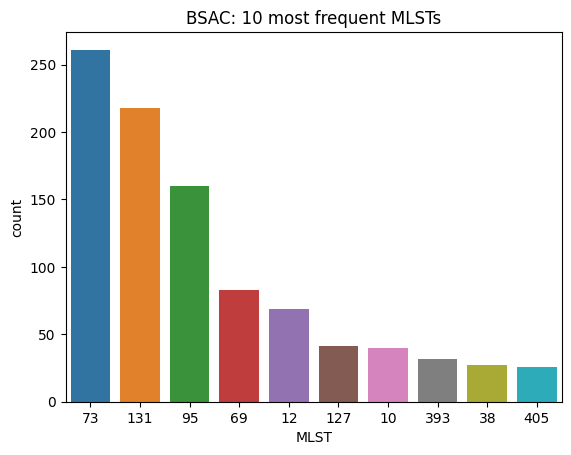

In [14]:
## ST counts
def get_n_most_freq(df, N, feat = "ST", data_id = "Data"):
    # Get N most frequent categorical feature values
    
    sns.countplot(data = df, x = feat, order = pd.value_counts(df[feat]).iloc[:N].index)
    plt.title(data_id + ": " + str(N) + " most frequent " + feat + "s")
    plt.show()
    
get_n_most_freq(bsac_data, N = 10, feat = "MLST", data_id = "BSAC")

#get_n_most_freq(norm_data, N = 10, feat = "ST", data_id = "NORM")

In [15]:
# Count the number of ST131 isolates and within that, the number of clade A, B, C1 and C2.
len(bsac_data[bsac_data["MLST"] == 131]) # 218
bsac_data.shape[0] # total number of isolates

1509

In [16]:
# get the distribution of STs in bsac data

# Part 3: ELFI

ST131 vs all. So baseline/defnition of a susceptible population = no ST131 colonization.

[ELFI documentation](https://elfi.readthedocs.io/en/latest/)

Components in ELFI graph
- TODO: Simulators, summaries etc.

Local installation:
- `pip3 install elfi`

### Questions
- What is the subject indicator here? Is there only one sample per subject?
- On what level are we modelling, subject or just observations? How to define "missingness" of some ST colonization if we don't have time series data from a single subject?

In [17]:
import elfi

### One vs all model

- Colonization explored on the level of ST. Colonzied, if there was a specific ST found. If not, not colonized.

$y$: colonized or not, 0 = no, 1 = yes


**Model**
- Priors?
- The model itself (some ODE? or just multiply by some rate parameter the number of colonized/suseceptible cases?)

In [18]:
[1]*10

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [19]:
# First, some reshaping of data: add y, whether an observation is colonized by the ST of interest or not

# initialize y with zeros
y = np.zeros(df.shape[0])
df["y"] = y
print(len(y))

# choose st of interest
st = 131

# update y
df.loc[df['ST'] == st] # 272 cases

3254


,lane,Run accession,popPUNK_cluster,ST,CC131_clades,Duplicate,year,Lab,Hospital name,Regional health authority,...,ESBL,Gentamicin_SIR,Meropenem_SIR,Nalidixin_SIR,Piperacillin_tazobactam_SIR,Sulfa_SIR,Tigecyklin_SIR,Tobramycin_SIR,Trimetoprim_sulfa_SIR,y
5,30134_6#107,ERR4034090,4,131,A,NaN,2014,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,+,R,S,NaN,S,NaN,S,NaN,R,0.0
12,30134_6#115,ERR4034096,4,131,B,NaN,2012,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,-,I,S,NaN,S,NaN,S,NaN,R,0.0
15,30134_6#119,ERR4034099,4,131,C1,NaN,2013,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,-,S,S,NaN,S,NaN,S,NaN,S,0.0
16,30134_6#120,ERR4034100,4,131,A,NaN,2011,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,-,S,S,NaN,S,NaN,S,NaN,S,0.0
35,30134_6#145,ERR4034119,4,131,C1,Triplicate from patient same ST,2014,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,-,S,S,NaN,S,NaN,S,NaN,S,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3210,31663_7#288,ERR4037496,4,131,C2,NaN,2015,Ahus,Akershus universitetssykehus,Helse Sør-Øst,...,-,S,S,NaN,S,NaN,NaN,NaN,S,0.0
3236,31663_7#381,ERR4037520,4,131,C1,NaN,2015,Ahus,Akershus universitetssykehus,Helse Sør-Øst,...,-,S,S,S,S,NaN,S,S,S,0.0
3242,31663_7#59,ERR4037439,4,131,C2,NaN,2014,Ahus,Akershus universitetssykehus,Helse Sør-Øst,...,-,S,S,NaN,S,NaN,S,NaN,R,0.0
3249,31663_7#85,ERR4037446,4,131,A,NaN,2014,Ahus,Akershus universitetssykehus,Helse Sør-Øst,...,-,S,S,NaN,S,NaN,NaN,NaN,S,0.0


# SIR model with least squares estimation

- Step 1: Create a simulator of your own DONE
- Step 2: Do some inference on the simulated data DONE simple least squares

In [20]:
# Building a simple SIR model using ELFI


def dS(S, I, t, beta, N):

    return -beta*S[t]*I[t]/N[t]

def dI(I, S, t,beta, alpha, N):
    
    return beta*S[t]*I[t]/N[t] - alpha*I[t]

def dR(I, t, alpha):
    
    return alpha*I[t]


def SIR(I0, R0, S0, N, T, beta, alpha, batch_size = 1, random_state = None):
    
    S = [S0]
    I = [I0]
    R = [R0]
    N = [N]*(len(T) - 1) #*(len(T)-1) # Assume a fixed population size over time.
    
    for t in T[0:(len(T)-1)]:
        
        # Update SIR model
        I.append(I[t] + dI(I, S, t, beta, alpha, N))
        R.append(R[t] + dR(I, t, alpha))
        S.append(S[t] + dS(S, I, t, beta, N))
        
    return S, I, R


# So I want to model how S, I, R develop with different parameters gamma and beta.

#dS(S=[100], I = [2], t = 0, beta = 0.2, N = [100]) # negative. Works I guess.

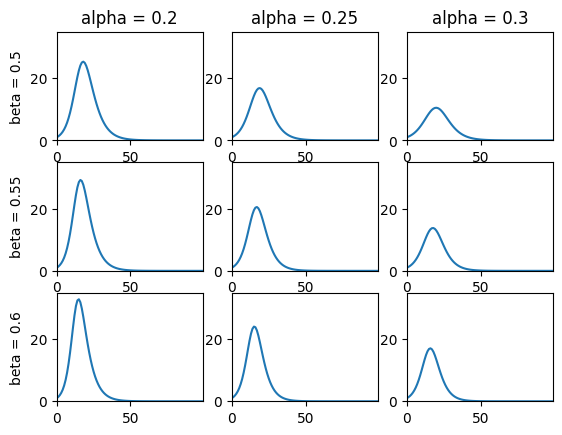

In [21]:
figure, axis = plt.subplots(3, 3)

betas = [0.5, 0.55, 0.6]
alphas = [0.2, 0.25, 0.3]

T = [i for i in range(0,100)] 

for i in range(0, 3):
    
    for j in range(0, 3):
        
        y = SIR(I0 = 1, R0 = 0, S0 = 99, N = 100, T=T, beta = betas[i], alpha = alphas[j])
        N = [100]*len(T)
        
        
        axis[i, j].plot(T, y[1])
        axis[i,j].set_xlim([0,max(T)])
        axis[i,j].set_ylim([0, 35])
        
        if i == 0:
            axis[i,j].set_title("alpha = " + str(alphas[j]))
        if j == 0:
            axis[i,j].set_ylabel("beta = " + str(betas[i]))

#plt.axis([0, max(T), 0, 30])
plt.show()

# because these are different, then I is enough to identify both parameters alpha and beta.
# (When you think about it, makes perfect sense. If the figures only changed with one of the parameters, then 
# we wouldn't be able to distinguish the other parameter.)

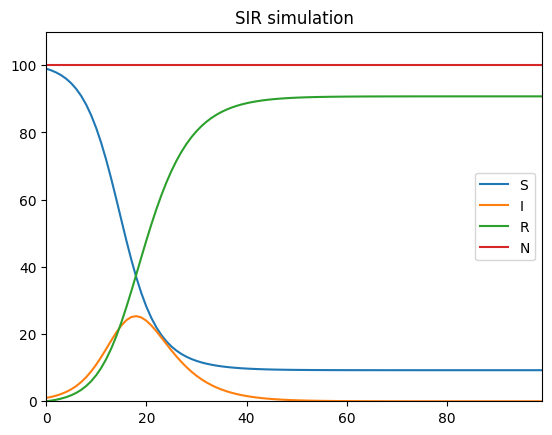

In [22]:
y = SIR(I0 = 1, R0 = 0, S0 = 99, N = 100, T=T, beta = 0.5, alpha = 0.2)
N = [100]*len(T)
plt.axis([0, max(T), 0, max(N) + 10])

S = y[0]
I = y[1]
R = y[2]

plt.plot(T, S)
plt.plot(T, I)
plt.plot(T, R)
plt.plot(T, N)
plt.title("SIR simulation")
plt.legend(["S", "I", "R", "N"])
plt.show()

In [23]:
np.array([1,2,3]) - np.array([1,0.2,4])

array([ 0. ,  1.8, -1. ])

In [24]:
T = [i for i in range(0,100)]
SIR_obs = SIR(I0 = 1, R0 = 0, S0 = 999, N = 1000, T=T, beta = 0.5, alpha = 0.2)
SIR_hat = SIR(I0 = 1, R0 = 0, S0 = 99, N = 100, T=T, beta = 0.1, alpha = 0.2)

In [25]:
# Based on simulated data, what is the value of beta and gamma?

# Basic least squares loss first

def least_squares_estimator(SIR_obs, N, T = 100, plot_loss = False):
    # Simple least squares estimator for calculating beta of a SIR model from data.
    # Assume same initial values as data
    
    I0 = np.ceil(min(SIR_obs[1]))
    R0 = np.ceil(min(SIR_obs[2]))
    S0 = np.ceil(max(SIR_obs[0]))
    
    print("Initial values:", I0, R0, S0)

    T = [i for i in range(0,T)]
    
    S_obs = SIR_obs[0]
    I_obs = SIR_obs[1]
    R_obs = SIR_obs[2]


    alpha = 0.2

    losses = []
    betas = []

    p_test = 0.4 # How much of the observed/simulated distribution is used to calculate the loss
    n_test = int(len(I_obs)*p_test)

    for b in np.arange(0, 2, 0.01): # Iterate over a range of potential values of beta

        new_SIR = SIR(I0, R0, S0, N, T, beta = b, alpha = alpha) # Simulated dataset at the value of beta

        # Compute loss on the number of infected patient
        loss_I = np.sum((np.array(new_SIR[1][0:n_test]) - np.array(I_obs[0:n_test]))**2)
        #loss_S = np.sum((np.array(new_SIR[0]) - np.array(S_obs))**2)
        losses.append(loss_I)
        betas.append(b)


    print("Smallest loss:", np.min(losses))
    print("Achieved at beta =", betas[losses.index(np.min(losses))])
    
    if plot_loss:
        plt.axis([0, max(betas), 0, np.median(losses)])
        plt.plot(betas, losses)
        plt.title("SSE loss vs beta")
        plt.xlabel("beta")
        plt.ylabel("SSE")
        plt.show()
        
        
    #return losses, betas
    

Initial values: 1.0 0.0 999.0
Smallest loss: 0.0
Achieved at beta = 0.5


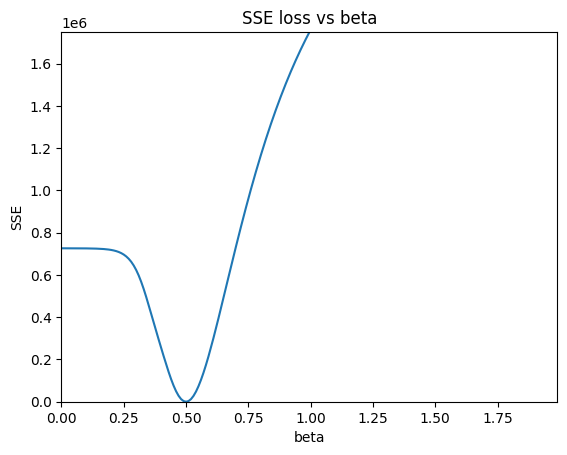

In [26]:
least_squares_estimator(SIR_obs, 1000, plot_loss = True)

# Simulating BSI
$N(OR, \sigma)$ What is this?
- I want to estimate OR based on the SIR model - and then compare that estimation with the actual OR, right? Or figure.

Invasiveness of E.coli is calculated as follows:

$inv = \frac{f_{carriage}}{f_{BSI}}$

C compartment
- Get the proportion of strain A vs everything else. Here, strain A = ST131
- Use this to get the odds ratio.
- Simulate BSI based on the odds ratio. 
- Compare simulated BSI with the data.
- Enjoy!!!


Note that invasiveness =/= force of colonization

Base carriage rate for E.coli is assumed constant over time and over all age groups.
- Where can I get this actually?


OR = 2 means that strain B is twice as likely to cause BSI non-B strains.


### SIR model in terms of proportions:

$$\frac{d\theta_S(t)}{dt} = -\beta\theta_S(t)\theta_I(t)$$

$$\frac{d\theta_I(t)}{dt} = \beta\theta_S(t)\theta_I(t) - \alpha\theta_I(t)$$

$$\frac{d\theta_R(t)}{dt} = \alpha\theta_I(t)$$

0.15384615384615385


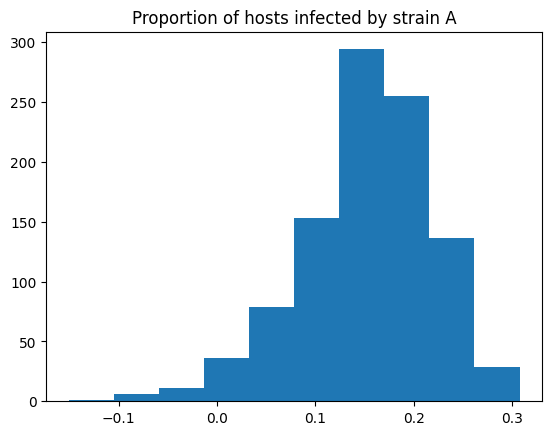

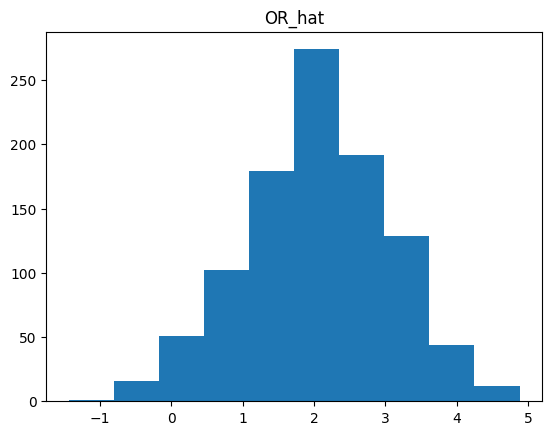

In [27]:
theta_a = 0.05 # carriage rate of strain A
theta_b = 0.55 # carriage rate of strain B
theta_c = 0.6 # overall carriage rate
OR = 2 # A is twice as infectious as B.
OR_hat = np.random.normal(OR, 1, 1000)

theta_bsi_a = OR*theta_a/(OR*theta_a + theta_b) # This now something we would know from the NORM and BSAC datasets, right?
print(theta_bsi_a)

theta_bsi_a_hat = OR_hat*theta_a/(OR_hat*theta_a + theta_b)


plt.title("Proportion of hosts infected by strain A")
plt.hist(theta_bsi_a_hat)
plt.show()


plt.title("OR_hat")
plt.hist(OR_hat)
plt.show()

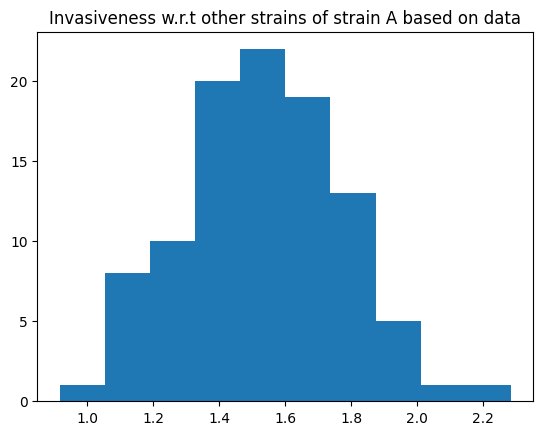

In [28]:
def OR_simulator(OR, sigma, n_obs = 100):
    # OR: odds ratio
    
    or_hat = np.random.normal(OR, sigma, size = n_obs)
    
    return or_hat
    
# From the data:
# - base carriage rate gamma (assumed constant over time)


def get_odds_ratio(p1, base_carriage_rate=0.6):
    # p1: proportion of hosts colonized with a certain strain
    
    pass



# Odds ratio for ST131: 1.5

OR_hat = OR_simulator(1.5, 0.25)
plt.hist(OR_hat)
plt.title("Invasiveness w.r.t other strains of strain A based on data") # not really. The OR does not depict that, but the difference between groups PP and nonPP but idk what these are.
plt.show()

# SIR model with ELFI

Thoughts:
- ELFI can handle a SIR model with multiple outputs (S, I, R counts namely)
    - Diagnosis: it can run, but will not yield correct results, at least not for a simple SIR model :)
    - It got beta right, but screwed up gamma
- Testing: return only the number of infected cases from `simpleSIR`
    - Now it gets gamma roughly right but not beta...
- TODO: really understand what goes on with ELFI.
- Ok seems to work with three returned lists?
- What would the y even be in a SIR model? Some summary statistic of these three


Lintusaari et al 2017:
- Tuberculosis example: number of infectious hosts used as the "y" here. Summary statistics based on genetic diversity and number of clusters (cluster = closely related strains(?))


Thoughts on the summary statistic:
- Mean number of infectious hosts is probably not the best, especially since the oserved data is simulated until all are in the R category. Solution: use observations up to a predefined number of infetious hosts, like 50. Solution 2: use something else as the summary statistic. Maybe even maximum number of infected/infectious hosts during the simulation?
- What if I attempt to use S and R as well for summary statistics?


In [23]:
def propSIR(params, batch_size = 1, random_state = None):
    # SIR model with proportions
    thetaS = [params["S0"]/params["N"]] # recommendation: make S0 the same as N - I0
    thetaI = [params["I0"]/params["N"]]
    thetaR = [params["R0"]/params["N"]]
    
    beta = params["beta"]
    gamma = params["gamma"]
    
    for t in params["times"][:-1]:
        
        dthetaS = -beta*thetaS[t]*thetaI[t]
        dthetaI = beta*thetaS[t]*thetaI[t] - gamma*thetaI[t]
        dthetaR = gamma*thetaI[t]
        
        thetaS.append(thetaS[t] + dthetaS)
        thetaI.append(thetaI[t] + dthetaI)
        thetaR.append(thetaR[t] + dthetaR)
    
    
    return thetaS, thetaI, thetaR

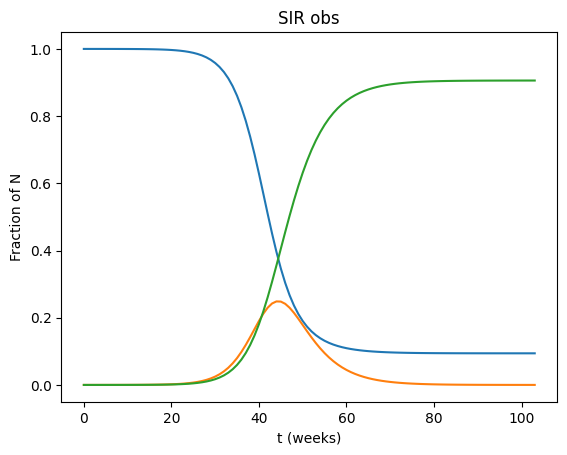

In [24]:
params = {"S0": 100000 - 1, "I0": 1, "R0":0, "beta":0.5, "gamma":0.2, "times":[i for i in range(0,104)],"timestep":1, "N":100000}
pSIR_obs = propSIR(params)

T = params["times"] # 1 t = 1 week
plt.plot(T, pSIR_obs[0])
plt.plot(T, pSIR_obs[1])
plt.plot(T, pSIR_obs[2])
plt.title("SIR obs")
plt.ylabel("Fraction of N")
plt.xlabel("t (weeks)")
plt.show()

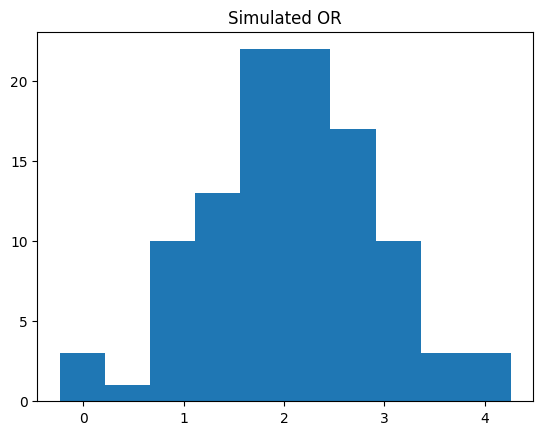

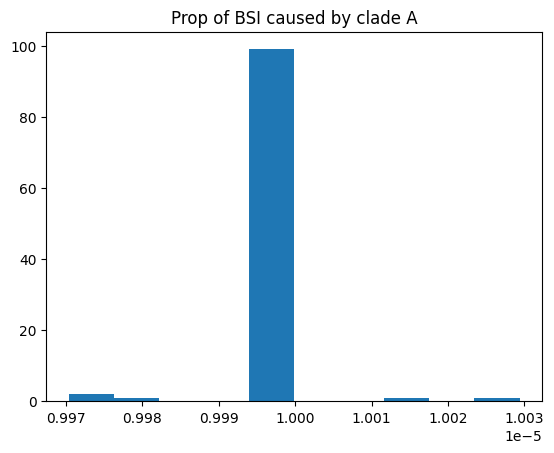

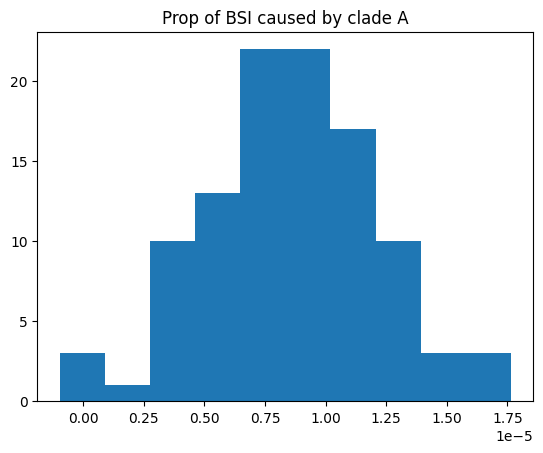

In [41]:
# From this simulated data, calculate the proportion of BSI

mu_OR = 2
var_OR = 1
OR_hat = np.random.normal(mu_OR, var_OR, size = len(pSIR_obs[0]))
plt.hist(OR_hat)
plt.title("Simulated OR")
plt.show()

thetaC = 0.6 # The carriage rate of ecoli
tau = 0.05 # proportion of BSIs in the population. Assumed known.

ca = max(pSIR_obs[1])*params["N"]
c0 = params["N"]*thetaC - ca

#da = OR_hat*ca*tau*params["N"]/(c0 + OR_hat*ca*tau*params["N"]) # number of BSI cases caused by clade A in the population
theta_da = OR_hat*(ca/params["N"])/(ca/params["N"] + c0/params["N"]) # this is probably more correct :)

plt.hist(da/params["N"])
plt.title("Prop of BSI caused by clade A")
plt.show()


plt.hist(theta_da/params["N"])
plt.title("Prop of BSI caused by clade A")
plt.show()

In [48]:
df["Label"] == "A (Combined)"

0     False
1     False
2      True
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
Name: Label, dtype: bool

In [52]:
# True value for theta_BSI, A from the data:

df = pd.read_csv("data/ST131_clades_OR_E_coli_carriage_disease_collapsed.csv")


clade = "A"
data = "Combined"
print(f'{clade} ({data})')
theta_BSI_a_true = df[df["Label"] == f'{clade} ({data})']["Disease_PP"]/df[df["Label"] == f'{clade} ({data})']["Disease_nonPP"]
theta_BSI_a_true

# The estimated value is way too small but yeehaw, it makes at least somewhat sense :)

A (Combined)


2    0.020133
dtype: float64

In [31]:
# let's make a simpler SIR for this
def simpleSIR(beta, alpha, nt = 100, N = 1000, batch_size = 1, random_state = None):
    
    # Use fixed initial values
    S = [N - 1]
    I = [1]
    R = [0]
    
    # Use a fixed length sequence
    T = [i for i in range(0,nt)]
    N = [N]*(len(T) - 1) #*(len(T)-1) # Assume a fixed population size over time.
    
    for t in T[0:(len(T)-1)]: # could this be vectorized for efficiency?
        
        # Update SIR model
        I.append(I[t] + dI(I, S, t, beta, alpha, N))
        R.append(R[t] + dR(I, t, alpha))
        S.append(S[t] + dS(S, I, t, beta, N))
        
    #return S, I, R
    return I


In [32]:
def sse(y1, y2):
    
    (np.array(y1) - np.array(y2))**2
    
def sumstat(y):
    
    #return np.mean(y)
    return np.max(y)


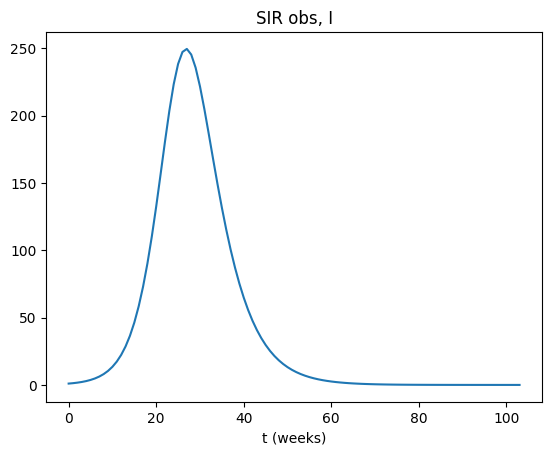

In [33]:
# Define simulator (can ELFI handle multiple y:s?)
SIR_obs = simpleSIR(beta = 0.5, alpha = 0.2, nt=104)

T = [i for i in range(0,104)] # 1 t = 1 week
plt.plot(T, SIR_obs)
plt.title("SIR obs, I")
plt.xlabel("t (weeks)")
plt.show()

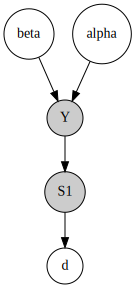

In [41]:
elfi.new_model()
# Define priors
beta = elfi.Prior(scipy.stats.uniform, 0, 2) # some random normal prior for beta
alpha = elfi.Prior(scipy.stats.norm, 0, 3)

Y = elfi.Simulator(simpleSIR, beta, alpha, observed=SIR_obs)
S1 = elfi.Summary(np.max, Y)
#S2 = elfi.Summary(np.var, Y)
d = elfi.Distance('euclidean', S1)
elfi.draw(d)

In [42]:
seed = 10
rej = elfi.Rejection(d, seed=seed)

In [43]:
# Looks like the sampling finds the correct value of gamma, but fails to converge properly for beta. 
# solution idea nro 1: use max(I) as summary statistic?

In [44]:
N = 100
#vis = dict(xlim=[-4,4], ylim=[-4,4])
%time result = rej.sample(N, quantile=0.01)

 /tmp/ipykernel_29660/3418027666.py:10: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_29660/3418027666.py:6: RuntimeWarning:overflow encountered in multiply
 /home/ojalaf2/.conda/envs/ecoli-elfi/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: VisibleDeprecationWarning:Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
 /tmp/ipykernel_29660/3418027666.py:10: RuntimeWarning:invalid value encountered in subtract


Progress [==================================================] 100.0% Complete
CPU times: user 18.6 s, sys: 337 ms, total: 18.9 s
Wall time: 18.5 s


In [45]:
print(result.samples['beta'].mean())
print(result.samples['alpha'].mean())

result.summary()

1.259743006677611
0.6263767768971331
Method: Rejection
Number of samples: 100
Number of simulations: 10000
Threshold: 43.3
Parameter                Mean               2.5%              97.5%
alpha:                  0.626              0.109              2.558
beta:                   1.260              0.286              1.977



array([[<AxesSubplot: ylabel='alpha'>, <AxesSubplot: >],
       [<AxesSubplot: xlabel='alpha', ylabel='beta'>,
        <AxesSubplot: xlabel='beta'>]], dtype=object)

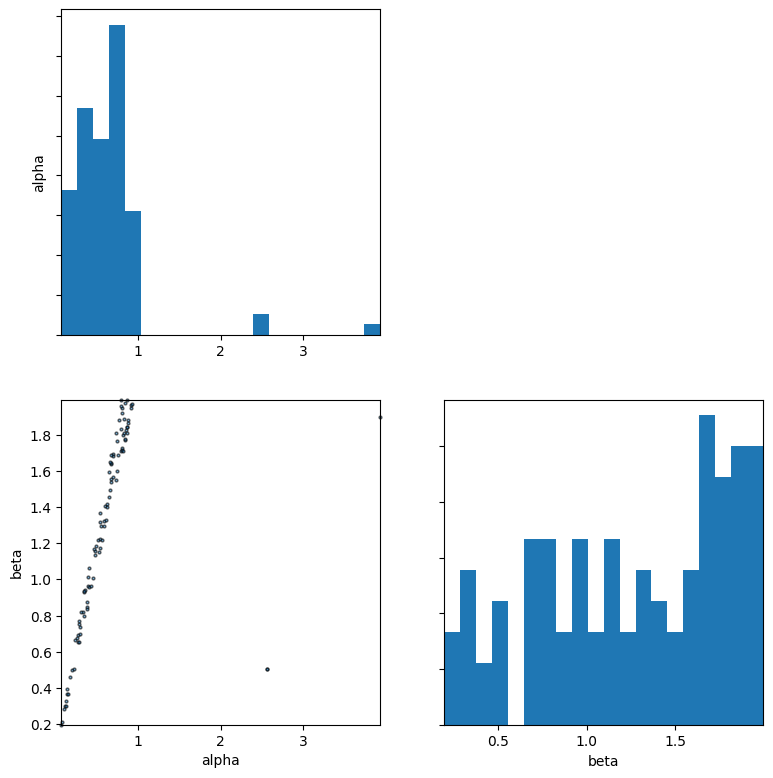

In [46]:
result.plot_pairs() # too little samples?